# 01 Example: Build a PHA Oligomer

This notebook shows the smallest useful iPHASimulator workflow: build one PHA molecule from a selected monomer and number of repeat units.

The naming used here distinguishes the building block from the resulting chain:

| Meaning | Example |
| --- | --- |
| Monomer | `3HB` |
| Polymer | `P3HB` |
| Oligomer with four repeat units | `P3HB_4` |

The other representative monomers are `3HO` and `3HDD`, which form `P3HO` and `P3HDD` chains.

## Step 1: Choose the molecule

This example builds `P3HB_4`: an R-stereochemical P3HB oligomer containing four 3HB repeat units. Change `monomer` or `repeat_units` to build a different molecule.

In [1]:
from iphasimulator.naming import oligomer_name

monomer = "3HB"  # Other examples: "3HO" or "3HDD"
repeat_units = 4
stereochemistry = "R"

polymer_name = oligomer_name(monomer, repeat_units)
polymer_name

'P3HB_4'

## Step 2: Build the PHA oligomer

`build_pha_chain` returns an RDKit molecule. The chain is represented as a linear hydroxy-acid oligomer.

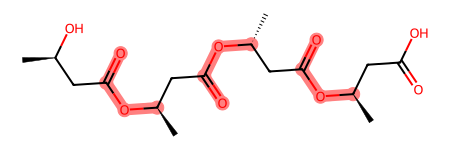

In [2]:
from iphasimulator.build import build_pha_chain

pha = build_pha_chain(
    monomer=monomer,
    n=repeat_units,
    stereochemistry=stereochemistry,
)
pha.SetProp("_Name", polymer_name)

pha

## Step 3: Check the result

The summary below confirms the molecule name, atom count, and stereochemical SMILES.

In [3]:
from rdkit import Chem

{
    "name": pha.GetProp("_Name"),
    "repeat_units": repeat_units,
    "atoms": pha.GetNumAtoms(),
    "smiles": Chem.MolToSmiles(pha, isomericSmiles=True),
}

{'name': 'P3HB_4',
 'repeat_units': 4,
 'atoms': 25,
 'smiles': 'C[C@H](CC(=O)O)OC(=O)C[C@@H](C)OC(=O)C[C@@H](C)OC(=O)C[C@@H](C)O'}

## Try another PHA

Return to Step 1 and change `monomer` to `"3HO"` or `"3HDD"`. Keep the first run small; larger oligomers take longer to parameterise in later notebooks.